# Lab 13: Normalizing Flows
**CMU 11-785: Introduction to Deep Learning**

**Attribution:**
* This lab is adapted from the "Normalizing Flows for Image Modeling" tutorial by **Phillip Lippe** (UvA Deep Learning Course).
* Original Source: [UvA Deep Learning Tutorials](https://uvadlc-notebooks.readthedocs.io/en/latest/)
* License: [MIT License](https://github.com/phlippe/uvadlc_notebooks/blob/master/LICENSE.md)

## Learning Objectives
1.  Understand the **Change of Variables Formula**.
2.  Implement an **Affine Coupling Layer** (the core of RealNVP).
3.  Train a Flow model to generate MNIST digits.

# Theory of Normalizing Flows

## Overview
**Recommended Reading:** For an excellent theoretical explanation of the math behind Flow-based models, check out [Lilian Weng's Blog Post](https://lilianweng.github.io/posts/2018-10-13-flow-models/).

Normalizing Flows are a class of generative models that learn an **exact** likelihood of the data distribution $p(x)$. Unlike GANs (which are adversarial) or VAEs (which optimize a lower bound), Normalizing Flows construct a probability distribution by transforming a simple base distribution (usually a Gaussian) into a complex data distribution using a sequence of **invertible** and **differentiable** mappings.

The process consists of two directions:
1.  **Inference (Normalizing):** Maps complex data $x$ to simple noise $z$ (used for training/density estimation).
2.  **Generation (Sampling):** Maps simple noise $z$ back to complex data $x$ (used for creating new images).

---

## Mathematical Formulation

### The Change of Variables Formula
Let $z$ be a random variable from a simple base distribution $p_z(z)$ (e.g., $\mathcal{N}(0, I)$).
Let $x$ be the complex data distribution.
We define an invertible mapping $f: Z \to X$ such that $x = f(z)$ and $z = f^{-1}(x)$.

To compute the probability density $p_x(x)$, we use the **Change of Variables Formula**, which accounts for how the volume of space expands or contracts during the transformation:

$$
p_x(x) = p_z(f^{-1}(x)) \cdot \left| \det \frac{\partial f^{-1}(x)}{\partial x} \right|
$$

In the log domain, this becomes:

$$
\log p_x(x) = \log p_z(z) + \log \left| \det \frac{\partial z}{\partial x} \right|
$$

where $\frac{\partial z}{\partial x}$ is the **Jacobian Matrix** of the inverse transformation.

### Composing Flows
To model complex data like images, a single transformation is not enough. We compose a sequence of $K$ invertible transformations:

$$
z_K = f_K \circ \dots \circ f_1(z_0), \quad \text{where } z_0 = x \text{ and } z_K = z
$$

The log-likelihood for the full chain is the sum of the log-determinants of each step:

$$
\log p_x(x) = \log p_z(z_K) + \sum_{k=1}^K \log \left| \det \frac{\partial f_k}{\partial z_{k-1}} \right|
$$

---

## Architecture: Affine Coupling Layers (RealNVP)
Computing the Jacobian determinant of a high-dimensional matrix (like an image) is computationally expensive ($O(D^3)$). Normalizing Flows require architectures where this calculation is efficient.

**RealNVP** introduces the **Affine Coupling Layer**, which splits the input $x$ into two halves ($x_a, x_b$) and transforms them as follows:

1.  **Forward (Inference $x \to z$):**
    \begin{aligned}
    z_a &= x_a \\
    z_b &= x_b \odot \exp(s(x_a)) + t(x_a)
    \end{aligned}
    
    Here, $s(\cdot)$ (scale) and $t(\cdot)$ (translation) are arbitrary neural networks (e.g., ResNets). They do **not** need to be invertible themselves.


2.  **Inverse (Generation $z \to x$):**
    \begin{aligned}
    x_a &= z_a \\
    x_b &= (z_b - t(z_a)) \odot \exp(-s(z_a))
    \end{aligned}

3.  **Jacobian Determinant:**
    Because $z_a$ does not depend on $x_b$, the Jacobian matrix is triangular. The determinant is simply the product of the diagonal elements:
    $$
    \log \left| \det \frac{\partial z}{\partial x} \right| = \sum \log | \exp(s(x_a)) | = \sum s(x_a)
    $$
    This is extremely efficient to compute.

Using device: cuda


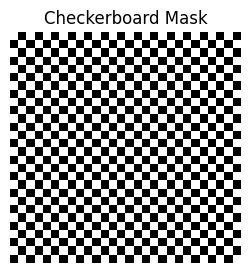

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Helper: Discretization (De-quantization)
# Flows model continuous densities. Images are discrete (0-255).
# We add uniform noise to make the data continuous.
def add_noise(x):
    """
    x: [Batch, 1, 28, 28] in range [0, 1]
    """
    noise = torch.rand_like(x) / 256.0
    return x + noise

# Helper: Create Checkerboard Mask
def create_checkerboard_mask(h, w, invert=False):
    x, y = torch.arange(h, dtype=torch.int32), torch.arange(w, dtype=torch.int32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    mask = (xx + yy) % 2 == 0
    mask = mask.to(torch.float32).view(1, 1, h, w)
    if invert:
        mask = 1 - mask
    return mask

# Visualize Checkerboard
plt.figure(figsize=(3,3))
plt.title("Checkerboard Mask")
plt.imshow(create_checkerboard_mask(28, 28)[0,0], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, num_channels, hidden_dim=128, mask_invert=False):
        """
        RealNVP Coupling Layer.
        Split data into two parts using a checkerboard mask.
        - Masked pixels are kept unchanged.
        - Unmasked pixels are transformed based on the masked pixels.
        """
        super().__init__()
        self.mask_invert = mask_invert

        # Simple ResNet-like block to predict Scale (s) and Translation (t)
        self.net = nn.Sequential(
            nn.Conv2d(num_channels, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, num_channels * 2, kernel_size=3, padding=1)
            # Output * 2 because we predict both s and t
        )

    def get_mask(self, x):
        h, w = x.shape[2], x.shape[3]
        mask = create_checkerboard_mask(h, w, self.mask_invert)
        return mask.to(x.device)

    def forward(self, x):
        """
        Forward pass (z -> x for generation, or x -> z for inference?
        Convention: x (data) -> z (noise) is usually the flow 'forward' in code).

        Returns:
            z: Transformed tensor
            log_det: Log determinant of the Jacobian
        """
        mask = self.get_mask(x)

        # 1. Mask the input
        x_masked = x * mask

        # 2. Predict s and t based on the masked image
        # The network sees the masked image and predicts how to transform the REST.
        out = self.net(x_masked)
        s, t = out.chunk(2, dim=1)

        # Stabilize scaling (s) using tanh
        s = torch.tanh(s)
        scale = torch.exp(s)

        # ======================== STUDENT TODO START ========================
        # Implement the Affine Coupling Transformation.
        # Formula: y = x_masked + (1 - mask) * (x * scale + t)
        #
        # 1. Apply the transformation ONLY to the unmasked pixels (where mask is 0).
        z = 
        # 2. The masked pixels (where mask is 1) should remain strictly unchanged.


        # Calculate Log Determinant
        # Since the matrix is triangular, the determinant is just the product of the diagonal terms (the scales).
        # log_det = Sum of log(scale) for all transformed pixels.
        # Hint: Use torch.sum() over the correct dimensions (everything except batch).
        # Note: Only sum the scales where (1 - mask) is active!

        log_det = 
        # ======================== STUDENT TODO END ==========================

        return z, log_det

    def inverse(self, z):
        """
        Inverse pass (z -> x).
        Used for sampling.
        """
        mask = self.get_mask(z)
        z_masked = z * mask

        out = self.net(z_masked)
        s, t = out.chunk(2, dim=1)
        s = torch.tanh(s)
        scale = torch.exp(s)

        # ======================== STUDENT TODO START ========================
        # Implement the INVERSE Affine Coupling Transformation.
        # Formula: x = (z - t) / scale   (for the unmasked parts)

        x = 

        # ======================== STUDENT TODO END ==========================

        return x

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, num_scales=4, in_channels=1):
        super().__init__()
        self.layers = nn.ModuleList()

        # Stack multiple coupling layers
        
        for i in range(num_scales):
            # ======================== STUDENT TODO START ========================
            # Alternate the mask (invert=False, then True) so we touch all pixels
           

            # ======================== STUDENT TODO END ==========================

    def forward(self, x):
        log_det_sum = 0
        for layer in self.layers:
            # ======================== STUDENT TODO START ========================
            # Call forward through all layers
        

            # ======================== STUDENT TODO END ==========================
        return x, log_det_sum

    def inverse(self, z):
        # ======================== STUDENT TODO START ========================
        # Call inverse through all layers

        
        # ======================== STUDENT TODO END ==========================
        return z

In [ ]:
import math
log_2pi = math.log(2*math.pi)

def compute_loss(model, x):
    # 1. Run the flow: x -> z
    z, log_det_jacobian = model(x)

    # ======================== STUDENT TODO START ========================
    # Implement the Negative Log Likelihood (NLL).
    #
    # NLL = - ( log p(z) + log |det J| )
    #
    # 1. Calculate log p(z). Assume z is Standard Normal N(0, I).
    #    log N(0, I) = -0.5 * (z^2 + log(2*pi))
    #    Sum this over all dimensions (1, 2, 3).
    #
    # 2. Add the log_det_jacobian.
    # 3. Return the negative mean of the result.


    # ======================== STUDENT TODO END ==========================

    return loss

In [ ]:
# Hyperparameters
BATCH_SIZE = 128
LR = 5e-4
EPOCHS = 10

# Load MNIST (Standard [0, 1])
transform = transforms.Compose([
    transforms.ToTensor() # NO Normalize here
])
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Init Model
model = RealNVP(num_scales=12).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training Loop
print("Starting Training...")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, _ in pbar:
        images = images.to(device)

        # De-quantization (Add Noise to fill gaps between integers)
        # MNIST is [0, 1]. We add noise up to 1/256.
        images = images + torch.rand_like(images) / 256.0

        optimizer.zero_grad()
        loss = compute_loss(model, images)

        # Stability Check (Gradient Clipping)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Add clipping
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'Loss': loss.item()})

    print(f"Epoch [{epoch+1}/{EPOCHS}], Avg Loss: {total_loss / len(train_loader):.4f}")

In [ ]:
x, _ = next(iter(train_loader))
x = x.to(device)
x = x + torch.rand_like(x) / 256.0   # whatever preprocessing you actually use

z, _ = model(x)
x_rec = model.inverse(z)
print("reconstruction error:", (x - x_rec).abs().mean().item())

# 2. Check that z is becoming ~Gaussian over training
with torch.no_grad():
    z, _ = model(x)
    print("z mean/std:", z.mean().item(), z.std().item())

In [ ]:
import torchvision.utils as vutils

# Sampling Function
def sample_images(model, num_samples=16):
    model.eval()
    with torch.no_grad():
        # 1. Sample from Prior z ~ N(0, 1)

        # 2. Inverse Flow: z -> x

        # 3. Clamp to valid image range [0, 1] for plotting

        raise NotImplemented

    return samples.cpu()

# Visualize
samples = sample_images(model)

# Plot grid
grid_img = torch.cat([samples[i][0] for i in range(16)], dim=1) # Simple concatenation
plt.figure(figsize=(10, 2))
plt.imshow(grid_img, cmap='gray')
plt.title("Generated Samples")
plt.axis('off')
plt.show()